In [11]:
import pandas as pd
import numpy as np
from functions import auxiliar_functions
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore', category=UserWarning)


plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
auxiliar_funcs = auxiliar_functions(start_date="2015-01-01", size=30)
df_total_ret = auxiliar_funcs.load_total_ret_df(timef="monthly")
df_mkt_cap = auxiliar_funcs.load_mcap(timef="monthly")
df_prices = auxiliar_funcs.load_prices(timef="monthly")

stocks = auxiliar_funcs.get_random_stocks(df_total_ret).tolist()
df_returns_stocks = df_total_ret[["Dates"] + list(stocks)]
df_mcap_stocks = df_mkt_cap[["Dates"] + list(stocks)]
df_prices_stocks = df_prices[["Dates"] + list(stocks)]

# Calculate monthly returns from monthly total return data
R_m = df_returns_stocks.set_index('Dates').pct_change().dropna()

print("Monthly returns:")
display(R_m.head(5))

Monthly returns:


,LMT UN Equity,EPAM UN Equity,GPC UN Equity,STT UN Equity,RSG UN Equity,SBAC UW Equity,HIG UN Equity,CMI UN Equity,AIZ UN Equity,LRCX UW Equity,...,KO UN Equity,CHD UN Equity,T UN Equity,CMG UN Equity,CBOE UF Equity,PWR UN Equity,CTRA UN Equity,CF UN Equity,TDY UN Equity,VRSK UW Equity
Dates,,,,,,,,,,,,,,,,,,,,,
2015-02-28,0.069917,0.260576,0.033785,0.041113,0.031249,0.068638,0.052957,0.025582,-0.030988,0.078755,...,0.051737,0.056453,0.049817,-0.063253,-0.064806,0.086858,0.094341,0.007755,0.060922,0.115929
2015-03-31,0.014546,-0.006323,-0.023736,-0.008347,-0.001915,-0.061022,0.025478,-0.025242,0.002285,-0.146348,...,-0.055892,0.003287,-0.055266,-0.021656,-0.043956,-0.008687,0.018274,-0.073638,0.058514,-0.005710
2015-04-30,-0.080606,0.055800,-0.035841,0.048823,0.001726,-0.010931,-0.025107,-0.002739,0.000815,0.076088,...,0.000246,-0.049754,0.076221,-0.044885,-0.019854,0.013319,0.145276,0.013361,-0.016490,0.050980
2015-05-31,0.016532,0.111266,0.006901,0.010503,-0.008368,-0.034623,0.012730,-0.014161,0.076265,0.088254,...,0.009862,0.038649,-0.002887,-0.009415,0.044253,0.014182,0.004731,0.104225,-0.034677,-0.032783
2015-06-30,-0.012223,-0.009456,-0.003684,-0.007530,-0.020827,0.028262,0.011189,-0.032164,0.017463,-0.007333,...,-0.034355,-0.033823,0.028373,-0.017059,-0.022881,-0.017053,-0.071259,0.017476,0.041251,0.002480


In [3]:
df_factors = auxiliar_funcs.load_common_factors_df()
display(df_factors.head(3))

✅ Momentum factor carregado: 1184 observações mensais


,Mkt-RF,SMB,HML,RMW,CMA,RF,MOM
Dates,,,,,,,
2015-01-31,-0.0309,-0.0093,-0.0345,0.0158,-0.0164,0.0,-0.0250
2015-02-28,0.0614,0.0036,-0.0179,-0.0110,-0.0175,0.0,-0.0017
2015-03-31,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0,-0.0024


In [4]:
# Model fama-french analysis
ff_cov_enhanced, betas_enhanced, r_squared = auxiliar_funcs.estimate_factor_model_covariance(
    R_m, df_factors,
    df_factors.columns.tolist(),
    resid_floor_pct=0,
    ridge_ratio=0,
    ensure_psd=False,
    return_r_squared=True
)

print("\n" + "="*60)
print("🔍 FAMA-FRENCH 6-FACTOR MODEL REGRESSION DIAGNOSTICS")
print("="*60)
print(f"\n📊 R² Statistics:")
print(f"   • Mean:    {r_squared.mean():.3f}")
print(f"   • Median:  {r_squared.median():.3f}")
print(f"   • Min:     {r_squared.min():.3f}")
print(f"   • Max:     {r_squared.max():.3f}")
print(f"\n✓ Model Fit Quality:")
print(f"   • Stocks with R² > 0.5:  {(r_squared > 0.5).sum()}/{len(r_squared)} ({(r_squared > 0.5).mean()*100:.1f}%)")
print(f"   • Stocks with R² > 0.7:  {(r_squared > 0.7).sum()}/{len(r_squared)} ({(r_squared > 0.7).mean()*100:.1f}%)")
print(f"   • Stocks with R² < 0.3:  {(r_squared < 0.3).sum()}/{len(r_squared)} ({(r_squared < 0.3).mean()*100:.1f}%)")
print("="*60 + "\n")



🔍 FAMA-FRENCH 6-FACTOR MODEL REGRESSION DIAGNOSTICS

📊 R² Statistics:
   • Mean:    0.405
   • Median:  0.431
   • Min:     0.161
   • Max:     0.724

✓ Model Fit Quality:
   • Stocks with R² > 0.5:  7/30 (23.3%)
   • Stocks with R² > 0.7:  1/30 (3.3%)
   • Stocks with R² < 0.3:  8/30 (26.7%)



### MVP comparison


🎯 How to interpret each factor:

1. Mkt-RF (Market Beta) - Blue:
   Beta > 1: Stock more volatile than market
   Beta < 1: Stock less volatile than market
   Example: TEL.UN has beta ~1.1 → rises 11% when market rises 10%


2. SMB (Size) - Green:
   Positive: Stock behaves like small cap
   Negative: Stock behaves like large cap
   Example: DD.UN has high SMB → it's a small cap


3. HML (Value vs Growth) - Red:
   Positive: Value stock (high book-to-market ratio)
   Negative: Growth stock (low book-to-market ratio)
   Example: JBHT.UW has negative HML → it's a growth stock


4. RMW (Profitability) - Purple:
   Positive: Stock from more profitable company
   Negative: Stock from less profitable company


5. CMA (Investment) - Yellow:
   Positive: Conservative company (low investment)
   Negative: Aggressive company (high investment)


6. MOM (Momentum) - Light Blue:
   Positive: Stock with positive momentum (uptrend)
   Negative: Stock with negative momentum (downtrend)



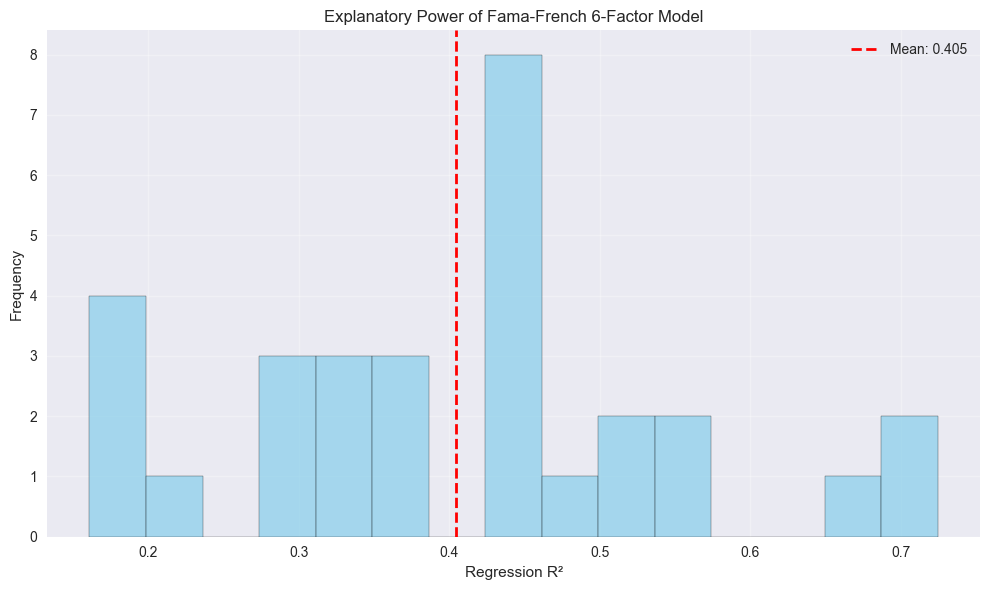

<Figure size 1500x800 with 0 Axes>

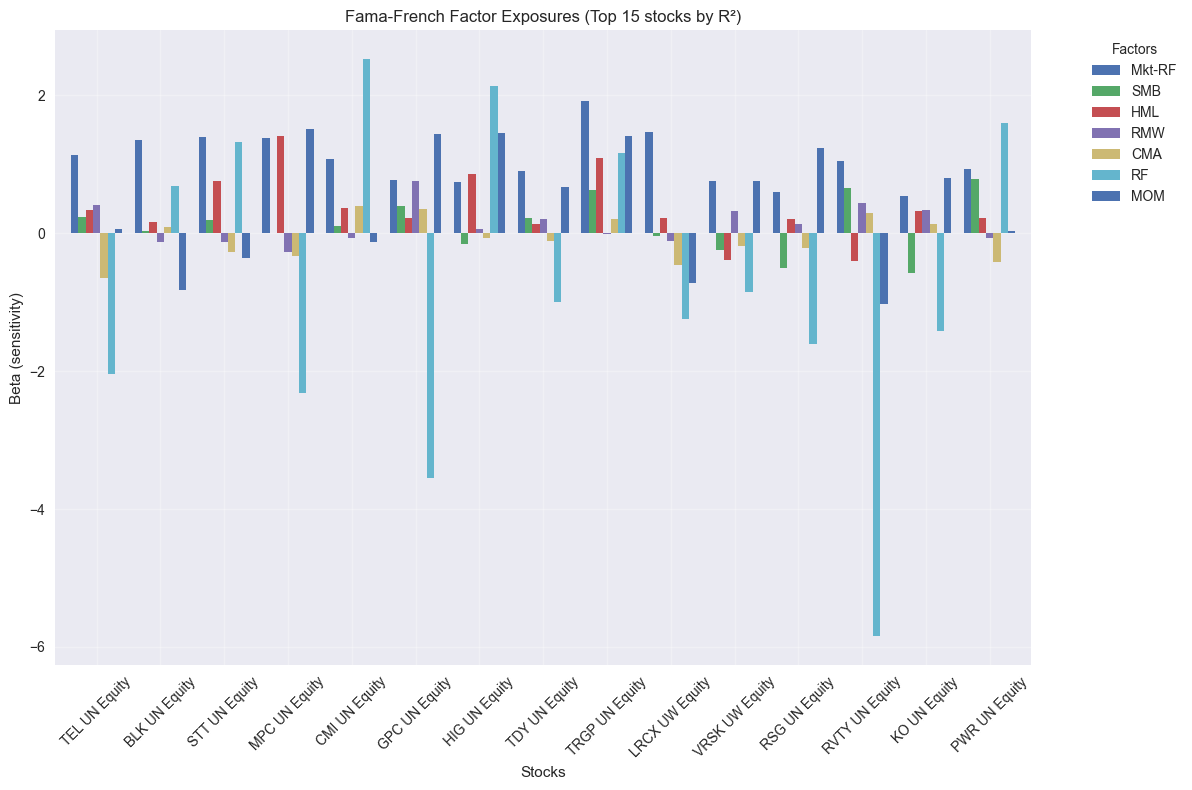


📋 BETA STATISTICS:


,Mkt-RF,SMB,HML,RMW,CMA,RF,MOM
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.894895,0.085149,0.176005,0.086651,-0.008140,-1.470496,0.422371
std,0.388426,0.386730,0.465516,0.389999,0.501372,3.811601,0.838393
min,0.337525,-0.576451,-0.946225,-0.764161,-1.154662,-13.509781,-1.757679
25%,0.585909,-0.189950,-0.042166,-0.120947,-0.316794,-2.487979,-0.088858
50%,0.837286,0.067230,0.213800,0.169567,-0.083716,-1.330916,0.571821
75%,1.111548,0.312769,0.327718,0.374055,0.346782,1.043221,1.008104
max,1.912619,0.784607,1.409287,0.750578,1.112774,5.025892,1.534994


In [5]:
print("""
🎯 How to interpret each factor:

1. Mkt-RF (Market Beta) - Blue:
   Beta > 1: Stock more volatile than market
   Beta < 1: Stock less volatile than market
   Example: TEL.UN has beta ~1.1 → rises 11% when market rises 10%


2. SMB (Size) - Green:
   Positive: Stock behaves like small cap
   Negative: Stock behaves like large cap
   Example: DD.UN has high SMB → it's a small cap


3. HML (Value vs Growth) - Red:
   Positive: Value stock (high book-to-market ratio)
   Negative: Growth stock (low book-to-market ratio)
   Example: JBHT.UW has negative HML → it's a growth stock


4. RMW (Profitability) - Purple:
   Positive: Stock from more profitable company
   Negative: Stock from less profitable company


5. CMA (Investment) - Yellow:
   Positive: Conservative company (low investment)
   Negative: Aggressive company (high investment)


6. MOM (Momentum) - Light Blue:
   Positive: Stock with positive momentum (uptrend)
   Negative: Stock with negative momentum (downtrend)
""")


# Chart 1: R² Distribution
plt.figure(figsize=(10, 6))
plt.hist(r_squared.values, bins=15, alpha=0.7, edgecolor='black', color='skyblue')
plt.axvline(r_squared.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {r_squared.mean():.3f}')
plt.xlabel('Regression R²')
plt.ylabel('Frequency')
plt.title('Explanatory Power of Fama-French 6-Factor Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Chart 2: Betas by factor (Top 15 stocks for readability)
plt.figure(figsize=(15, 8))
top_stocks = r_squared.nlargest(15).index
betas_enhanced.loc[top_stocks].plot(kind='bar', width=0.8)
plt.title('Fama-French Factor Exposures (Top 15 stocks by R²)')
plt.xlabel('Stocks')
plt.ylabel('Beta (sensitivity)')
plt.legend(title='Factors', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()


print("\n📋 BETA STATISTICS:")
display(betas_enhanced.describe())

In [6]:
def calculate_mvp_weights(cov_matrix):
    """
    Solve the Minimum Variance Portfolio (MVP) problem:
    min w'Σw sujeito a w'1 = 1
    
    solution: w = (Σ⁻¹1) / (1'Σ⁻¹1)
    """
    Sigma = cov_matrix.values
    ones = np.ones(len(cov_matrix))
    sigma_inv_ones = np.linalg.solve(Sigma, ones)
    weights = sigma_inv_ones / (ones @ sigma_inv_ones)
    return pd.Series(weights, index=cov_matrix.index)

def compare_mvp_estimators(monthly_returns, factors_data):
    # Empirical MVP
    emp_cov = monthly_returns.cov() * 12
    mvp_weights_emp = calculate_mvp_weights(emp_cov)
    
    # MVP using Fama-French 5-Factor Model
    ff_cov, betas, r_squared = auxiliar_funcs.estimate_factor_model_covariance(
        R_m, factors_data,
        factors_data.columns.tolist(),
        resid_floor_pct=0,
        ridge_ratio=0,
        ensure_psd=False,
        return_r_squared=True
    )
    ff_cov_annual = ff_cov * 12
    mvp_weights_ff = calculate_mvp_weights(ff_cov_annual)
    
    return {
        'empirical': mvp_weights_emp,
        'fama_french': mvp_weights_ff,
        'emp_cov': emp_cov,
        'ff_cov': ff_cov_annual,
        'betas': betas,
        'r_squared': r_squared
    }

In [7]:
comparison = compare_mvp_estimators(R_m, df_factors)


print("\n" + "="*70)
print("🎯 MINIMUM VARIANCE PORTFOLIO (MVP) COMPARISON")
print("="*70)

weights_comparison = pd.DataFrame({
    'Sample Covariance': comparison['empirical'],
    'Factor-Based Covariance': comparison['fama_french']
})

print("\n📈 WEIGHT DISTRIBUTION STATISTICS:")
print("-" * 70)
stats_summary = pd.DataFrame({
    'Metric': ['Max Absolute Weight', 'Min Weight', 'Mean Absolute Weight', 
               'Std Dev of Weights', 'Number of Positions'],
    'Sample Cov': [
        f"{comparison['empirical'].abs().max():.2%}",
        f"{comparison['empirical'].min():.2%}",
        f"{comparison['empirical'].abs().mean():.2%}",
        f"{comparison['empirical'].std():.4f}",
        f"{(comparison['empirical'].abs() > 0.001).sum()}"
    ],
    'Factor-Based Cov': [
        f"{comparison['fama_french'].abs().max():.2%}",
        f"{comparison['fama_french'].min():.2%}",
        f"{comparison['fama_french'].abs().mean():.2%}",
        f"{comparison['fama_french'].std():.4f}",
        f"{(comparison['fama_french'].abs() > 0.001).sum()}"
    ]
})
display(stats_summary.set_index('Metric'))


🎯 MINIMUM VARIANCE PORTFOLIO (MVP) COMPARISON

📈 WEIGHT DISTRIBUTION STATISTICS:
----------------------------------------------------------------------


,Sample Cov,Factor-Based Cov
Metric,,
Max Absolute Weight,14.64%,17.16%
Min Weight,-8.46%,-5.73%
Mean Absolute Weight,5.60%,5.30%
Std Dev of Weights,0.0635,0.0590
Number of Positions,30,30


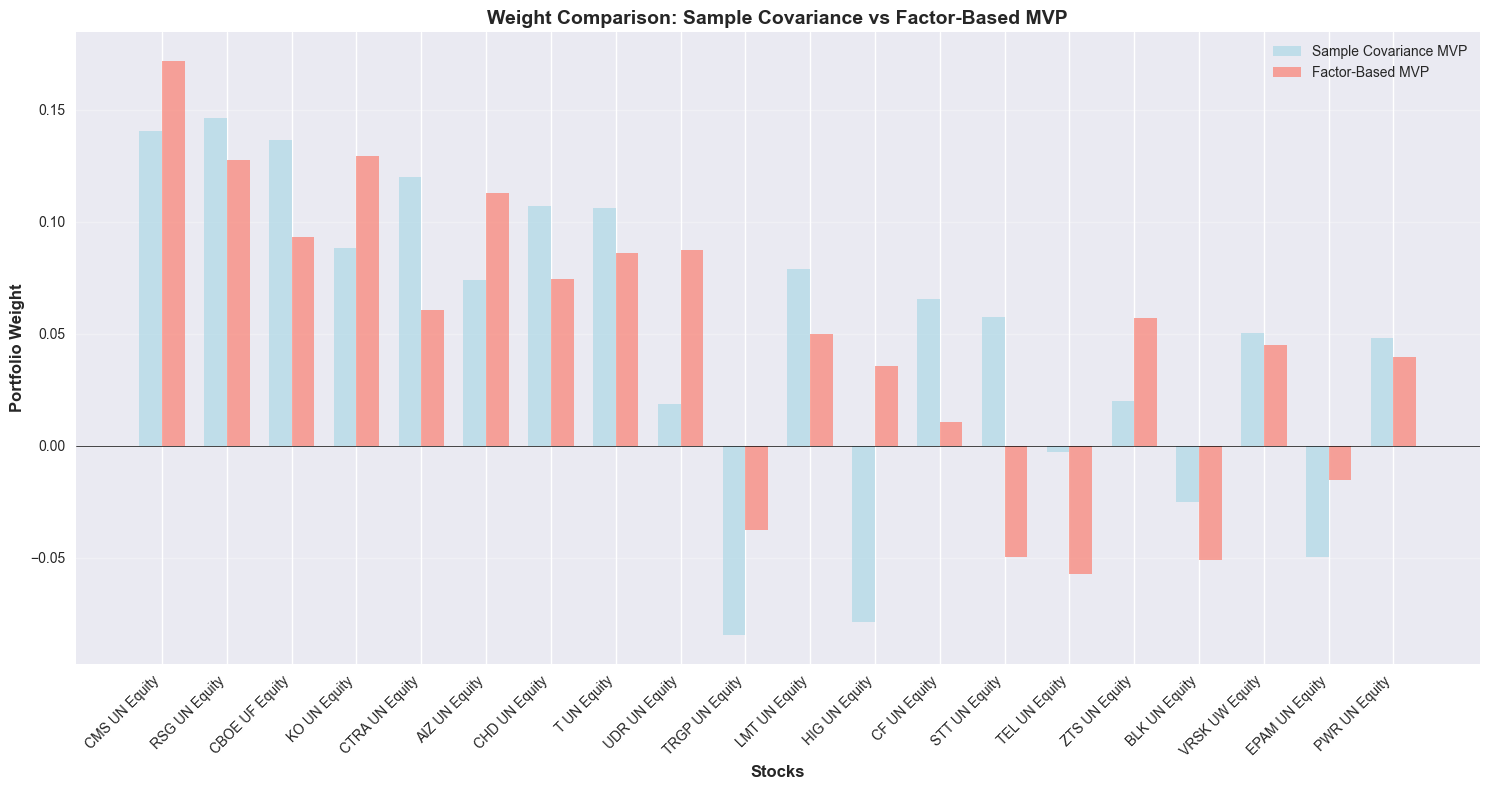

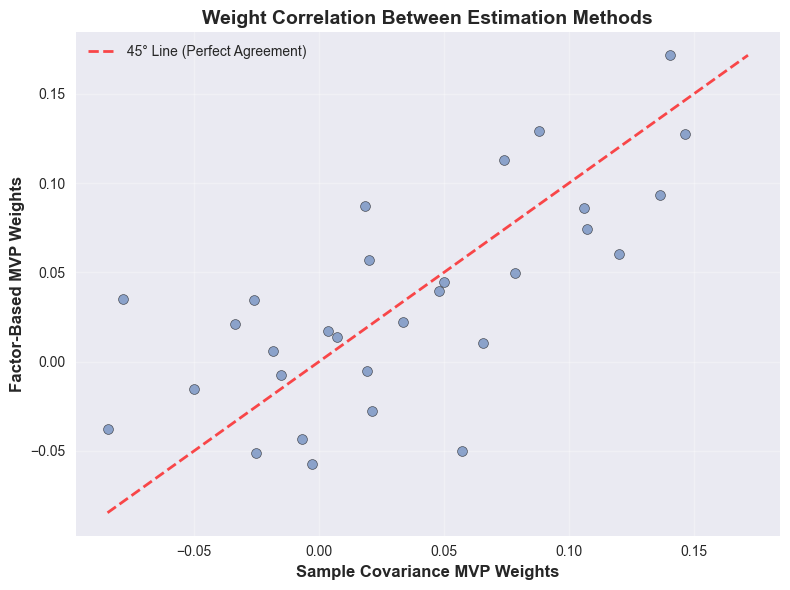

In [8]:
plt.figure(figsize=(15, 8))

top_stocks = weights_comparison.abs().max(axis=1).nlargest(20).index
weights_to_plot = weights_comparison.loc[top_stocks]

x = np.arange(len(weights_to_plot))
width = 0.35

plt.bar(x - width/2, weights_to_plot['Sample Covariance'], width, 
        label='Sample Covariance MVP', alpha=0.7, color='lightblue')
plt.bar(x + width/2, weights_to_plot['Factor-Based Covariance'], width, 
        label='Factor-Based MVP', alpha=0.7, color='salmon')

plt.xlabel('Stocks', fontsize=12, fontweight='bold')
plt.ylabel('Portfolio Weight', fontsize=12, fontweight='bold')
plt.title('Weight Comparison: Sample Covariance vs Factor-Based MVP', 
          fontsize=14, fontweight='bold')
plt.xticks(x, weights_to_plot.index, rotation=45, ha='right')
plt.legend(fontsize=10, loc='upper right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(weights_comparison['Sample Covariance'], weights_comparison['Factor-Based Covariance'], 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('Sample Covariance MVP Weights', fontsize=12, fontweight='bold')
plt.ylabel('Factor-Based MVP Weights', fontsize=12, fontweight='bold')
plt.title('Weight Correlation Between Estimation Methods', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

min_val = min(weights_comparison.min())
max_val = max(weights_comparison.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, 
         linewidth=2, label='45° Line (Perfect Agreement)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
print("COVARIANCE MATRIX COMPARISON:")
print("=" * 70)

emp_cov = comparison['emp_cov']
print(f"\n[1] SAMPLE COVARIANCE MATRIX (Empirical):")
print(f"   Dimension:           {emp_cov.shape[0]}x{emp_cov.shape[1]}")
print(f"   Average volatility:  {np.sqrt(np.diag(emp_cov)).mean():.2%}")
print(f"   Average correlation: {emp_cov.corr().values[np.triu_indices_from(emp_cov.corr().values, k=1)].mean():.3f}")

ff_cov = comparison['ff_cov']
print(f"\n[2] FACTOR-BASED COVARIANCE MATRIX (Fama-French):")
print(f"   Dimension:           {ff_cov.shape[0]}x{ff_cov.shape[1]}")
print(f"   Average volatility:  {np.sqrt(np.diag(ff_cov)).mean():.2%}")
print(f"   Average correlation: {ff_cov.corr().values[np.triu_indices_from(ff_cov.corr().values, k=1)].mean():.3f}")

print(f"\nSAMPLE COVARIANCE MATRIX (5x5 Sample):")
display(emp_cov.iloc[:5, :5].round(6))

print(f"\nFACTOR-BASED COVARIANCE MATRIX (5x5 Sample):")
display(ff_cov.iloc[:5, :5].round(6))


COVARIANCE MATRIX COMPARISON:

[1] SAMPLE COVARIANCE MATRIX (Empirical):
   Dimension:           30x30
   Average volatility:  27.89%
   Average correlation: 0.273

[2] FACTOR-BASED COVARIANCE MATRIX (Fama-French):
   Dimension:           30x30
   Average volatility:  28.43%
   Average correlation: 0.384

SAMPLE COVARIANCE MATRIX (5x5 Sample):


,LMT UN Equity,EPAM UN Equity,GPC UN Equity,STT UN Equity,RSG UN Equity
LMT UN Equity,0.045103,0.010405,0.017077,0.022277,0.011007
EPAM UN Equity,0.010405,0.181693,0.040569,0.058708,0.031286
GPC UN Equity,0.017077,0.040569,0.055341,0.034899,0.018499
STT UN Equity,0.022277,0.058708,0.034899,0.091513,0.013832
RSG UN Equity,0.011007,0.031286,0.018499,0.013832,0.025937



FACTOR-BASED COVARIANCE MATRIX (5x5 Sample):


,LMT UN Equity,EPAM UN Equity,GPC UN Equity,STT UN Equity,RSG UN Equity
LMT UN Equity,0.046913,0.017513,0.017766,0.021933,0.010134
EPAM UN Equity,0.017513,0.190498,0.029376,0.051275,0.021535
GPC UN Equity,0.017766,0.029376,0.057894,0.036630,0.013716
STT UN Equity,0.021933,0.051275,0.036630,0.094422,0.019537
RSG UN Equity,0.010134,0.021535,0.013716,0.019537,0.026589


In [10]:
def analyze_concentration_simple(weights_emp, weights_ff):
    """
    Simple concentration analysis using basic metrics
    """
    print("CONCENTRATION ANALYSIS:")
    print("=" * 50)
    
    # Maximum weight (concentration)
    max_weight_emp = weights_emp.abs().max()
    max_weight_ff = weights_ff.abs().max()
    
    # Number of stocks with weight > 5%
    high_weight_emp = (weights_emp.abs() > 0.05).sum()
    high_weight_ff = (weights_ff.abs() > 0.05).sum()
    
    # Sum of top 5 largest weights
    top5_emp = weights_emp.abs().nlargest(5).sum()
    top5_ff = weights_ff.abs().nlargest(5).sum()
    
    print(f"Maximum weight:")
    print(f"  • Sample Cov:       {max_weight_emp:.2%}")
    print(f"  • Factor-based:     {max_weight_ff:.2%}")
    
    print(f"\nStocks with weight > 5%:")
    print(f"  • Sample Cov:       {high_weight_emp}")
    print(f"  • Factor-based:     {high_weight_ff}")
    
    print(f"\nSum of top 5 weights:")
    print(f"  • Sample Cov:       {top5_emp:.2%}")
    print(f"  • Factor-based:     {top5_ff:.2%}")
    
    # Conclusion
    less_concentrated = "Factor-based" if max_weight_ff < max_weight_emp else "Sample Cov"
    print(f"\nResult: {less_concentrated} portfolio is less concentrated")

analyze_concentration_simple(comparison['empirical'], comparison['fama_french'])


CONCENTRATION ANALYSIS:
Maximum weight:
  • Sample Cov:       14.64%
  • Factor-based:     17.16%

Stocks with weight > 5%:
  • Sample Cov:       14
  • Factor-based:     12

Sum of top 5 weights:
  • Sample Cov:       65.03%
  • Factor-based:     63.46%

Result: Sample Cov portfolio is less concentrated


In [26]:
def to_excess_returns(returns_df, factors_df):
    rf = factors_df['RF'].reindex(returns_df.index).fillna(method='ffill')
    return returns_df.sub(rf, axis=0)

def _ensure_psd(S, floor_ratio=1e-8):
    """Garante PSD via floor nos autovalores."""
    vals, vecs = np.linalg.eigh((S + S.T) / 2)
    lam_min = np.maximum(vals, floor_ratio * np.trace(S) / S.shape[0])
    return (vecs @ np.diag(lam_min) @ vecs.T)

def _corr_from_cov(S):
    d = np.sqrt(np.clip(np.diag(S), 1e-14, None))
    return S / np.outer(d, d)

def mvp_weights_closed_form(Sigma):
    """w* = Σ^{-1}1 / (1'Σ^{-1}1), robusto a singularidade."""
    n = Sigma.shape[0]
    ones = np.ones(n)
    S = Sigma.values
    try:
        x = np.linalg.solve(S, ones)
    except np.linalg.LinAlgError:
        x = np.linalg.pinv(S) @ ones
    w = x / (ones @ x)
    return pd.Series(w, index=Sigma.index)

def mvp_weights_constrained(Sigma, long_only=True, cap=0.10):
    """
    SLSQP: min 0.5 w' Σ w s.a. 1'w=1 e bounds.
    """
    n = Sigma.shape[0]
    S = Sigma.values
    def obj(w):
        return 0.5 * w @ S @ w
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},)
    if long_only:
        bounds = [(0.0, cap) for _ in range(n)]
    else:
        bounds = [(-cap, cap) for _ in range(n)]

    w0 = np.ones(n) / n
    res = minimize(obj, w0, method='SLSQP', bounds=bounds, constraints=cons,
                   options={'maxiter': 500, 'ftol': 1e-12, 'disp': False})
    if not res.success:
        # fallback robusto
        w = mvp_weights_closed_form(Sigma)
        if long_only:
            w = w.clip(lower=0)
            w = w / w.sum()
        return w
    return pd.Series(res.x, index=Sigma.index)

def backtest_mvp_out_of_sample(
    monthly_returns, factors_data,
    lookback_months=36,
    min_stocks=10,
    long_only=True,
    cap=0.15,
    use_constrained=True,
    verbose=True
):
    """
    Rebalanceia todo mês. Em cada data t:
      - define ativos negociáveis (sem NaN em t);
      - reestima Σ_emp e Σ_fator nesse subconjunto;
      - calcula pesos (conforme flags) e aplica aos retornos de t.
    """

    idx = monthly_returns.index.intersection(factors_data.index)
    R = monthly_returns.loc[idx].copy()
    F = factors_data.loc[idx].copy()


    if verbose:
        print("📅 Backtest OOS")
        print(f"Janela (meses): solicitado={lookback_months}")
        print(f"Amostra: {R.index[0].date()} → {R.index[-1].date()}")

    results = []
    w_hist_emp, w_hist_ff = [], []

    for i in range(lookback_months, len(R)):
        date = R.index[i]

        # Ativos disponíveis no mês corrente
        avail_now = R.columns[R.iloc[i].notna()]
        if len(avail_now) < min_stocks:
            continue

        # Janela de estimação
        past_R_all = R.iloc[i - lookback_months:i]
        # Exigir presença suficiente na janela
        valid = past_R_all.dropna(axis=1, thresh=int(0.8 * lookback_months)).columns
        avail = avail_now.intersection(valid)
        if len(avail) < min_stocks:
            continue

        past_R = past_R_all[avail]
        r_t   = R.iloc[i][avail]

        # Σ EMPÍRICA (com ridge adaptativo)
        emp_cov = past_R.cov()  # mensal
        ridge_emp = 1e-4 * (np.trace(emp_cov.values) / emp_cov.shape[0])
        emp_cov = pd.DataFrame(_ensure_psd(emp_cov.values + ridge_emp * np.eye(len(avail))),
                               index=avail, columns=avail)

        # Σ FATORIAL completa
        ff_cov, _, _ = auxiliar_funcs.estimate_factor_model_covariance(
            past_R, F.iloc[i - lookback_months:i],
            df_factors.columns.tolist(),
            resid_floor_pct=20,
            ridge_ratio=1e-4,
            ensure_psd=True,
            return_r_squared=False
        )
        
        # Pesos (opção: fechado ou com restrições)
        if use_constrained:
            w_emp = mvp_weights_constrained(emp_cov, long_only=long_only, cap=cap)
            w_ff  = mvp_weights_constrained(ff_cov,  long_only=long_only, cap=cap)
        else:
            w_emp = mvp_weights_closed_form(emp_cov)
            w_ff  = mvp_weights_closed_form(ff_cov)

        # Aplicar aos retornos do mês t
        port_emp = float((w_emp * r_t).sum())
        port_ff  = float((w_ff  * r_t).sum())

        # Guardar
        results.append({
            'Date': date,
            'Portfolio_Return_Empirical': port_emp,
            'Portfolio_Return_FactorBased': port_ff,
            'N_Stocks': len(avail),
            'Gross_emp': float(np.abs(w_emp).sum()),
            'Gross_ff':  float(np.abs(w_ff).sum())
        })
        w_hist_emp.append((date, w_emp))
        w_hist_ff.append((date, w_ff))

    res_df = pd.DataFrame(results).set_index('Date')
    if verbose:
        print(f"✓ Rebals: {len(res_df)}")
        if len(res_df):
            print(f"Gross médio (emp, ff): {res_df['Gross_emp'].mean():.2f}, {res_df['Gross_ff'].mean():.2f}")
    return res_df, w_hist_emp, w_hist_ff

In [27]:
backtest_results, w_emp_hist, w_ff_hist = backtest_mvp_out_of_sample(
    R_m, df_factors, lookback_months=24, long_only=True, cap=0.15, use_constrained=True
)

📅 Backtest OOS
Janela (meses): solicitado=24
Amostra: 2015-02-28 → 2025-06-30
✓ Rebals: 101
Gross médio (emp, ff): 1.00, 1.00


In [ ]:
def analyze_oos_complete(backtest_results, w_hist_emp, w_hist_ff, rf_series=None):
    """
    Comprehensive OOS analysis with all metrics:
    - Performance (return, vol, Sharpe, CAGR)
    - Risk (max drawdown)
    - Concentration (ENB, HHI)
    - Trading costs (turnover)
    """
    df = backtest_results.copy()
    
    if rf_series is not None and len(df):
        rf = rf_series.reindex(df.index).fillna(0)
        df['Portfolio_Return_Empirical'] = df['Portfolio_Return_Empirical'] - rf
        df['Portfolio_Return_FactorBased'] = df['Portfolio_Return_FactorBased'] - rf
    
    # Extract return series
    emp_r = df['Portfolio_Return_Empirical'].dropna()
    ff_r = df['Portfolio_Return_FactorBased'].dropna()
    
    # 1. PERFORMANCE METRICS   
    def ann_mean(r): return r.mean() * 12
    def ann_vol(r): return r.std(ddof=1) * np.sqrt(12)
    def cagr(r): return (1 + r).prod()**(12/len(r)) - 1 if len(r) > 0 else np.nan
    def sharpe(r): 
        return (ann_mean(r) / ann_vol(r)) if ann_vol(r) > 0 else np.nan
    
    def max_drawdown(r):
        """Maximum peak-to-trough decline"""
        if len(r) == 0: return np.nan
        cumulative = (1 + r).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown.min()
    
    perf = {
        'emp_return_ann': ann_mean(emp_r),
        'ff_return_ann': ann_mean(ff_r),
        'emp_cagr': cagr(emp_r),
        'ff_cagr': cagr(ff_r),
        'emp_vol_ann': ann_vol(emp_r),
        'ff_vol_ann': ann_vol(ff_r),
        'emp_sharpe': sharpe(emp_r),
        'ff_sharpe': sharpe(ff_r),
        'emp_max_dd': max_drawdown(emp_r),
        'ff_max_dd': max_drawdown(ff_r),
        'corr_ports': emp_r.corr(ff_r)
    }
    
    # 2. CONCENTRATION METRICS (ENB, HHI)
    def collect_weights(w_hist):
        """Normalize weights and stack into matrix"""
        W = []
        for _, w in w_hist:
            w_norm = w / w.sum()
            W.append(w_norm.values)
        return np.array(W) if W else np.empty((0,))
    
    W_emp = collect_weights(w_hist_emp)
    W_ff = collect_weights(w_hist_ff)
    
    if W_emp.size and W_ff.size:
        # Herfindahl-Hirschman Index
        hhi_emp = np.mean(np.sum(W_emp**2, axis=1))
        hhi_ff = np.mean(np.sum(W_ff**2, axis=1))
        
        perf['ENB_emp'] = 1 / hhi_emp  # Effective Number of Bets
        perf['ENB_ff'] = 1 / hhi_ff
        perf['max_abs_w_emp'] = float(np.max(np.abs(W_emp)))
        perf['max_abs_w_ff'] = float(np.max(np.abs(W_ff)))
        perf['mean_abs_w_emp'] = float(np.mean(np.abs(W_emp)))
        perf['mean_abs_w_ff'] = float(np.mean(np.abs(W_ff)))
    
    # 3. TURNOVER (Trading Costs Proxy)   
    def avg_turnover(w_hist):
        """Average monthly turnover: 0.5 * sum(|w_t - w_{t-1}|)"""
        if len(w_hist) < 2: return np.nan
        
        turnovers = []
        for i in range(1, len(w_hist)):
            _, w_prev = w_hist[i-1]
            _, w_curr = w_hist[i]
            
            # Union of tickers (handle stocks entering/exiting)
            idx = w_prev.index.union(w_curr.index)
            v_prev = w_prev.reindex(idx, fill_value=0).values
            v_curr = w_curr.reindex(idx, fill_value=0).values
            
            turnovers.append(0.5 * np.sum(np.abs(v_curr - v_prev)))
        
        return float(np.mean(turnovers))
    
    perf['turnover_emp'] = avg_turnover(w_hist_emp)
    perf['turnover_ff'] = avg_turnover(w_hist_ff)
    
    return perf

# PRETTY PRINT FUNCTION
def print_oos_report(metrics, lookback_months=None):
    """
    Professional formatted report of OOS metrics
    """
    print("\n" + "="*80)
    print("OUT-OF-SAMPLE BACKTEST RESULTS")
    if lookback_months:
        print(f"Lookback Window: {lookback_months} months")
    print("="*80)
    
    # Performance
    print("\n📈 PERFORMANCE METRICS (Annualized)")
    print("-" * 80)
    print(f"{'Metric':<25} {'Sample Cov':>15} {'Factor-Based':>15} {'Difference':>15}")
    print("-" * 80)
    
    # Returns
    print(f"{'Mean Return':<25} {metrics['emp_return_ann']:>14.2%} {metrics['ff_return_ann']:>14.2%} "
          f"{metrics['ff_return_ann'] - metrics['emp_return_ann']:>14.2%}")
    print(f"{'CAGR':<25} {metrics['emp_cagr']:>14.2%} {metrics['ff_cagr']:>14.2%} "
          f"{metrics['ff_cagr'] - metrics['emp_cagr']:>14.2%}")
    
    # Risk
    print(f"{'Volatility':<25} {metrics['emp_vol_ann']:>14.2%} {metrics['ff_vol_ann']:>14.2%} "
          f"{metrics['ff_vol_ann'] - metrics['emp_vol_ann']:>14.2%}")
    print(f"{'Maximum Drawdown':<25} {metrics['emp_max_dd']:>14.2%} {metrics['ff_max_dd']:>14.2%} "
          f"{metrics['ff_max_dd'] - metrics['emp_max_dd']:>14.2%}")
    
    # Risk-adjusted
    print(f"{'Sharpe Ratio':<25} {metrics['emp_sharpe']:>14.3f} {metrics['ff_sharpe']:>14.3f} "
          f"{metrics['ff_sharpe'] - metrics['emp_sharpe']:>14.3f}")
    
    # Concentration
    if 'ENB_emp' in metrics:
        print("\n⚖️ CONCENTRATION METRICS")
        print("-" * 80)
        print(f"{'Effective # of Bets':<25} {metrics['ENB_emp']:>14.2f} {metrics['ENB_ff']:>14.2f} "
              f"{metrics['ENB_ff'] - metrics['ENB_emp']:>14.2f}")
        print(f"{'Max Absolute Weight':<25} {metrics['max_abs_w_emp']:>14.2%} {metrics['max_abs_w_ff']:>14.2%}")
        print(f"{'Mean Absolute Weight':<25} {metrics['mean_abs_w_emp']:>14.2%} {metrics['mean_abs_w_ff']:>14.2%}")
    
    # Turnover
    print("\n🔄 TRADING COSTS")
    print("-" * 80)
    print(f"{'Avg Monthly Turnover':<25} {metrics['turnover_emp']:>14.2%} {metrics['turnover_ff']:>14.2%} "
          f"{metrics['turnover_ff'] - metrics['turnover_emp']:>14.2%}")
    
    # Transaction cost impact (assume 10 bps = 0.1%)
    tc_impact_emp = metrics['turnover_emp'] * 0.001 * 12  # Annual impact
    tc_impact_ff = metrics['turnover_ff'] * 0.001 * 12
    print(f"{'Est. TC Impact (10bps)':<25} {tc_impact_emp:>14.2%} {tc_impact_ff:>14.2%}")
    
    # Net returns after TC
    net_emp = metrics['emp_return_ann'] - tc_impact_emp
    net_ff = metrics['ff_return_ann'] - tc_impact_ff
    print(f"{'Net Return (after TC)':<25} {net_emp:>14.2%} {net_ff:>14.2%} "
          f"{net_ff - net_emp:>14.2%}")
    
    # Summary
    print("\n✅ SUMMARY")
    print("-" * 80)
    winner = "Factor-Based" if metrics['ff_sharpe'] > metrics['emp_sharpe'] else "Sample Cov"
    print(f"  • {winner} achieves superior risk-adjusted performance")
    print(f"  • Portfolio correlation: {metrics['corr_ports']:.3f}")
    print("="*80 + "\n")

# Run backtest
backtest_results, w_emp_hist, w_ff_hist = backtest_mvp_out_of_sample(
    R_m, df_factors, 
    lookback_months=24,
    long_only=True, 
    cap=0.15
)

# Comprehensive analysis
metrics = analyze_oos_complete(
    backtest_results, 
    w_emp_hist, 
    w_ff_hist,
    rf_series=df_factors.get('RF')
)

# Pretty print
print_oos_report(metrics, lookback_months=24)


📅 Backtest OOS
Janela (meses): solicitado=24
Amostra: 2015-02-28 → 2025-06-30
✓ Rebals: 101
Gross médio (emp, ff): 1.00, 1.00

OUT-OF-SAMPLE BACKTEST RESULTS
Lookback Window: 24 months

📈 PERFORMANCE METRICS (Annualized)
--------------------------------------------------------------------------------
Metric                         Sample Cov    Factor-Based      Difference
--------------------------------------------------------------------------------
Mean Return                       13.64%         13.61%         -0.03%
CAGR                              13.21%         13.44%          0.24%
Volatility                        15.29%         13.70%         -1.59%
Maximum Drawdown                 -23.02%        -16.86%          6.16%
Sharpe Ratio                       0.892          0.994          0.102

⚖️ CONCENTRATION METRICS
--------------------------------------------------------------------------------
Effective # of Bets                 8.41          10.09           1.68
Max Absolu

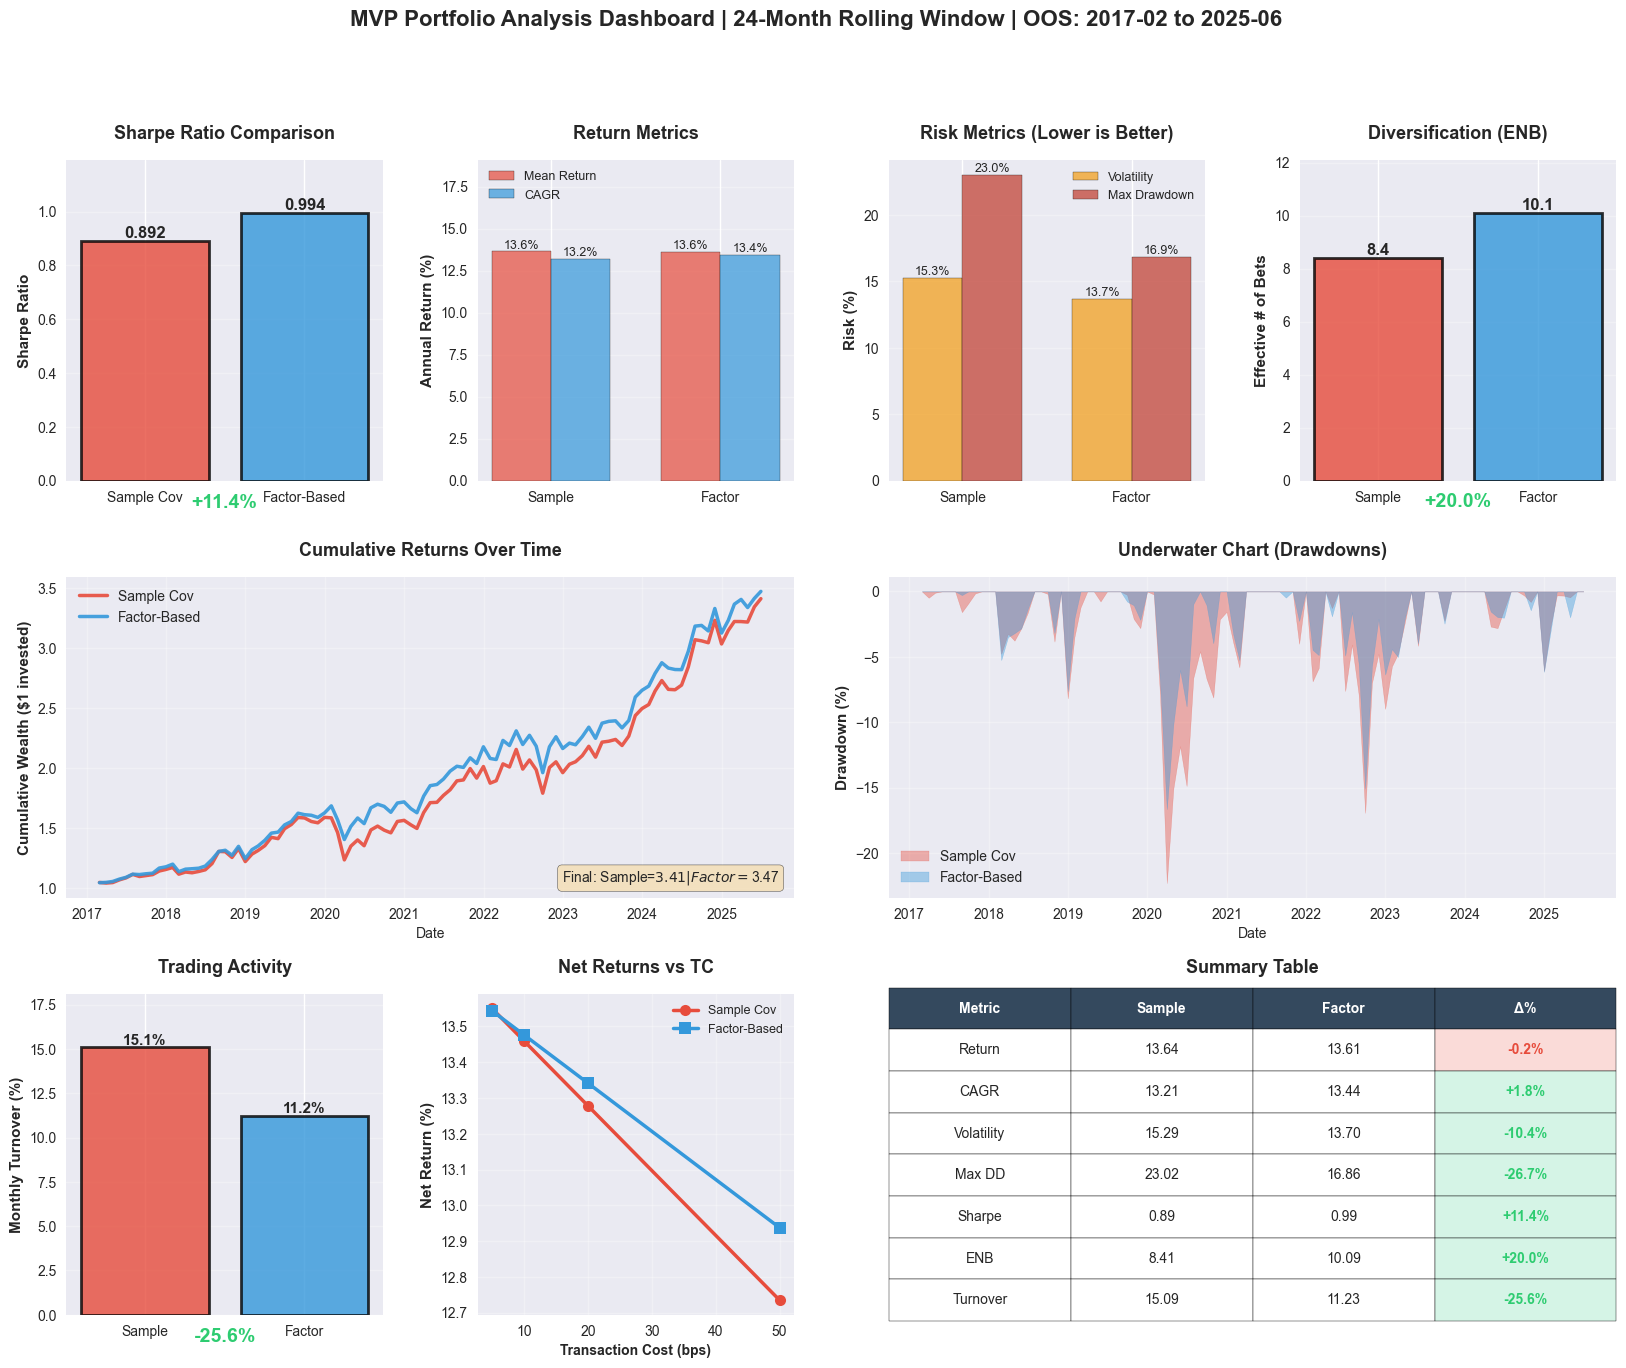

In [71]:
def create_oos_dashboard(backtest_results, metrics, lookback_months=24):    
    plt.style.use('seaborn-v0_8-darkgrid')
    colors = {
        'emp': '#E74C3C',      # Red for Sample
        'ff': '#3498DB',       # Blue for Factor
        'better': '#2ECC71',   # Green for improvements
        'worse': '#E74C3C'     # Red for worse
    }
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # 1. SHARPE RATIO COMPARISON (Large, top-left)
    ax1 = fig.add_subplot(gs[0, 0])
    
    sharpes = [metrics['emp_sharpe'], metrics['ff_sharpe']]
    bars = ax1.bar(['Sample Cov', 'Factor-Based'], sharpes, 
                   color=[colors['emp'], colors['ff']], alpha=0.8, edgecolor='black', linewidth=2)
    
    # Add value labels on bars
    for bar, val in zip(bars, sharpes):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold') 
        
    improvement = (metrics['ff_sharpe'] - metrics['emp_sharpe']) / metrics['emp_sharpe'] * 100
    ax1.text(0.5, -0.1, f'+{improvement:.1f}%', 
             ha='center', fontsize=14, fontweight='bold', 
             color=colors['better'], transform=ax1.transData)
        
    ax1.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
    ax1.set_title('Sharpe Ratio Comparison', fontsize=13, fontweight='bold', pad=15)
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim(0, max(sharpes) * 1.2)
    
    # 2. RETURNS COMPARISON
    ax2 = fig.add_subplot(gs[0, 1])
    
    x = np.arange(2)
    width = 0.35
    
    mean_rets = [metrics['emp_return_ann']*100, metrics['ff_return_ann']*100]
    cagrs = [metrics['emp_cagr']*100, metrics['ff_cagr']*100]
    
    bars1 = ax2.bar(x - width/2, mean_rets, width, label='Mean Return', 
                    color=colors['emp'], alpha=0.7, edgecolor='black')
    bars2 = ax2.bar(x + width/2, cagrs, width, label='CAGR', 
                    color=colors['ff'], alpha=0.7, edgecolor='black')
    
    ax2.set_ylabel('Annual Return (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Return Metrics', fontsize=13, fontweight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Sample', 'Factor'])
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    cagrs.extend(mean_rets)
    ax2.set_ylim(0, max(cagrs) * 1.4)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # 3. RISK METRICS
    ax3 = fig.add_subplot(gs[0, 2])
    
    vols = [metrics['emp_vol_ann']*100, metrics['ff_vol_ann']*100]
    mdds = [abs(metrics['emp_max_dd']*100), abs(metrics['ff_max_dd']*100)]
    
    x = np.arange(2)
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, vols, width, label='Volatility', 
                    color='#F39C12', alpha=0.7, edgecolor='black')
    bars2 = ax3.bar(x + width/2, mdds, width, label='Max Drawdown', 
                    color='#C0392B', alpha=0.7, edgecolor='black')
    
    ax3.set_ylabel('Risk (%)', fontsize=11, fontweight='bold')
    ax3.set_title('Risk Metrics (Lower is Better)', fontsize=13, fontweight='bold', pad=15)
    ax3.set_xticks(x)
    ax3.set_xticklabels(['Sample', 'Factor'])
    ax3.legend(loc='upper right', fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # 4. DIVERSIFICATION (ENB)
    ax4 = fig.add_subplot(gs[0, 3])
    
    enbs = [metrics['ENB_emp'], metrics['ENB_ff']]
    bars = ax4.bar(['Sample', 'Factor'], enbs, 
                   color=[colors['emp'], colors['ff']], alpha=0.8, edgecolor='black', linewidth=2)
    
    for bar, val in zip(bars, enbs):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        
    improvement = (metrics['ENB_ff'] - metrics['ENB_emp']) / metrics['ENB_emp'] * 100
    ax4.text(0.5, -1, f'+{improvement:.1f}%', 
             ha='center', fontsize=14, fontweight='bold', 
             color=colors['better'], transform=ax4.transData)
        
    ax4.set_ylabel('Effective # of Bets', fontsize=11, fontweight='bold')
    ax4.set_title('Diversification (ENB)', fontsize=13, fontweight='bold', pad=15)
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim(0, max(enbs) * 1.2)
    
    # 5. CUMULATIVE RETURNS (Wide plot)
    ax5 = fig.add_subplot(gs[1, :2])
    
    df = backtest_results.copy()
    emp_cumret = (1 + df['Portfolio_Return_Empirical']).cumprod()
    ff_cumret = (1 + df['Portfolio_Return_FactorBased']).cumprod()
    
    ax5.plot(emp_cumret.index, emp_cumret.values, 
             label='Sample Cov', color=colors['emp'], linewidth=2.5, alpha=0.9)
    ax5.plot(ff_cumret.index, ff_cumret.values, 
             label='Factor-Based', color=colors['ff'], linewidth=2.5, alpha=0.9)
    
    ax5.set_ylabel('Cumulative Wealth ($1 invested)', fontsize=11, fontweight='bold')
    ax5.set_title('Cumulative Returns Over Time', fontsize=13, fontweight='bold', pad=15)
    ax5.legend(loc='upper left', fontsize=10, framealpha=0.9)
    ax5.grid(True, alpha=0.3)
    ax5.set_xlabel('Date', fontsize=10)
    
    # Add final values
    final_emp = emp_cumret.iloc[-1]
    final_ff = ff_cumret.iloc[-1]
    ax5.text(0.98, 0.05, f'Final: Sample=${final_emp:.2f} | Factor=${final_ff:.2f}',
             transform=ax5.transAxes, ha='right', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 6. DRAWDOWN COMPARISON
    ax6 = fig.add_subplot(gs[1, 2:])
    
    # Calculate running drawdowns
    def calc_drawdown(ret_series):
        cumulative = (1 + ret_series).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown * 100
    
    emp_dd = calc_drawdown(df['Portfolio_Return_Empirical'])
    ff_dd = calc_drawdown(df['Portfolio_Return_FactorBased'])
    
    ax6.fill_between(emp_dd.index, emp_dd.values, 0, 
                     label='Sample Cov', color=colors['emp'], alpha=0.4)
    ax6.fill_between(ff_dd.index, ff_dd.values, 0, 
                     label='Factor-Based', color=colors['ff'], alpha=0.4)
    
    ax6.set_ylabel('Drawdown (%)', fontsize=11, fontweight='bold')
    ax6.set_title('Underwater Chart (Drawdowns)', fontsize=13, fontweight='bold', pad=15)
    ax6.legend(loc='lower left', fontsize=10)
    ax6.grid(True, alpha=0.3)
    ax6.set_xlabel('Date', fontsize=10)
    
    # 7. TURNOVER COMPARISON
    ax7 = fig.add_subplot(gs[2, 0])
    
    tos = [metrics['turnover_emp']*100, metrics['turnover_ff']*100]
    bars = ax7.bar(['Sample', 'Factor'], tos, 
                   color=[colors['emp'], colors['ff']], alpha=0.8, edgecolor='black', linewidth=2)
    
    for bar, val in zip(bars, tos):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    reduction = (metrics['turnover_emp'] - metrics['turnover_ff']) / metrics['turnover_emp'] * 100
    ax7.text(0.5, -1.5, f'-{reduction:.1f}%', 
             ha='center', fontsize=14, fontweight='bold', 
             color=colors['better'], transform=ax7.transData)
    
    ax7.set_ylabel('Monthly Turnover (%)', fontsize=11, fontweight='bold')
    ax7.set_title('Trading Activity', fontsize=13, fontweight='bold', pad=15)
    ax7.grid(axis='y', alpha=0.3)
    ax7.set_ylim(0, max(tos) * 1.2)
    
    # 8. TRANSACTION COSTS IMPACT
    ax8 = fig.add_subplot(gs[2, 1])
    
    tc_scenarios = [5, 10, 20, 50]  # bps
    emp_net = []
    ff_net = []
    
    for tc_bps in tc_scenarios:
        tc = tc_bps / 10000  # Convert bps to decimal
        emp_net.append((metrics['emp_return_ann'] - metrics['turnover_emp'] * tc * 12) * 100)
        ff_net.append((metrics['ff_return_ann'] - metrics['turnover_ff'] * tc * 12) * 100)
    
    ax8.plot(tc_scenarios, emp_net, 'o-', label='Sample Cov', 
             color=colors['emp'], linewidth=2.5, markersize=8)
    ax8.plot(tc_scenarios, ff_net, 's-', label='Factor-Based', 
             color=colors['ff'], linewidth=2.5, markersize=8)
    
    ax8.set_xlabel('Transaction Cost (bps)', fontsize=10, fontweight='bold')
    ax8.set_ylabel('Net Return (%)', fontsize=11, fontweight='bold')
    ax8.set_title('Net Returns vs TC', fontsize=13, fontweight='bold', pad=15)
    ax8.legend(loc='upper right', fontsize=9)
    ax8.grid(True, alpha=0.3)
    
    # 9. METRICS HEATMAP
    ax9 = fig.add_subplot(gs[2, 2:])
    
    metrics_names = ['Return', 'CAGR', 'Volatility', 'Max DD', 'Sharpe', 'ENB', 'Turnover']
    emp_vals = [
        metrics['emp_return_ann']*100,
        metrics['emp_cagr']*100,
        metrics['emp_vol_ann']*100,
        abs(metrics['emp_max_dd']*100),
        metrics['emp_sharpe'],
        metrics['ENB_emp'],
        metrics['turnover_emp']*100
    ]
    ff_vals = [
        metrics['ff_return_ann']*100,
        metrics['ff_cagr']*100,
        metrics['ff_vol_ann']*100,
        abs(metrics['ff_max_dd']*100),
        metrics['ff_sharpe'],
        metrics['ENB_ff'],
        metrics['turnover_ff']*100
    ]
    
    improvements = []
    for i, (e, f) in enumerate(zip(emp_vals, ff_vals)):
        if i in [2, 3, 6]:  # Volatility, Max DD, Turnover (lower is better)
            improvements.append((f - e) / e * 100)
        else:  # Others (higher is better)
            improvements.append((f - e) / e * 100)
    
    table_data = []
    for name, emp, ff, imp in zip(metrics_names, emp_vals, ff_vals, improvements):
        table_data.append([name, f'{emp:.2f}', f'{ff:.2f}', f'{imp:+.1f}%'])
    
    ax9.axis('tight')
    ax9.axis('off')
    
    table = ax9.table(cellText=table_data,
                      colLabels=['Metric', 'Sample', 'Factor', 'Δ%'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.25, 0.25, 0.25, 0.25])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.5)
    
    for i in range(4):
        table[(0, i)].set_facecolor('#34495E')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(1, len(table_data) + 1):
        val = float(table_data[i-1][3].strip('%+'))
        if val > 0:
            if table_data[i-1][0] in ['Volatility', 'Max DD', 'Turnover']:
                # Negative improvement for risk metrics
                table[(i, 3)].set_facecolor('#FADBD8')
                table[(i, 3)].set_text_props(weight='bold', color=colors['worse'])
            else:
                table[(i, 3)].set_facecolor('#D5F4E6')
                table[(i, 3)].set_text_props(weight='bold', color=colors['better'])
        else:
            if table_data[i-1][0] in ['Volatility', 'Max DD', 'Turnover']:
                # Positive improvement for risk metrics
                table[(i, 3)].set_facecolor('#D5F4E6')
                table[(i, 3)].set_text_props(weight='bold', color=colors['better'])
            else:
                table[(i, 3)].set_facecolor('#FADBD8')
                table[(i, 3)].set_text_props(weight='bold', color=colors['worse'])
    
    ax9.set_title('Summary Table', fontsize=13, fontweight='bold', pad=15)
    
    fig.suptitle(f'MVP Portfolio Analysis Dashboard | {lookback_months}-Month Rolling Window | OOS: {df.index[0].strftime("%Y-%m")} to {df.index[-1].strftime("%Y-%m")}',
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    return fig

fig = create_oos_dashboard(backtest_results, metrics, lookback_months=24)

plt.savefig('oos_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()